In [2]:
import pandas as pd

df = pd.read_csv("/content/sinh_vien.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

# Cột qua_mon chỉ có hai giá trị, đếm số lần xuất hiện từng giá trị
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()

print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

# So sánh số giờ ôn trung bình của hai nhóm
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


In [3]:
import numpy as np


def sigmoid(z):
    """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
    return 1 / (1 + np.exp(-z))


print("Bang gia tri cua ham sigmoid")
print("   z    sigmoid(z)")

for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
    print(f"{z:3d}    {sigmoid(z):.4f}")
print()

# Hai tính chất cần tự kiểm chứng
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
    trai = sigmoid(-z)
    phai = 1 - sigmoid(z)
    print(f"  z={z}: {trai:.6f} va {phai:.6f}")
print()

# Thử với một mô hình giả định w = 0.4 và b = -5
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w={w}, b={b}")
print(" So gio on    z = w*x + b    Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
    z = w * gio + b
    print(f" {gio:5.1f}        {z:6.2f}            {sigmoid(z):.4f}")

Bang gia tri cua ham sigmoid
   z    sigmoid(z)
 -6    0.0025
 -4    0.0180
 -2    0.1192
 -1    0.2689
  0    0.5000
  1    0.7311
  2    0.8808
  4    0.9820
  6    0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
  z=1.0: 0.268941 va 0.268941
  z=2.5: 0.075858 va 0.075858
  z=3.7: 0.024127 va 0.024127

Mo hinh gia dinh: w=0.4, b=-5.0
 So gio on    z = w*x + b    Xac suat qua mon
   5.0         -3.00            0.0474
  10.0         -1.00            0.2689
  12.5          0.00            0.5000
  15.0          1.00            0.7311
  20.0          3.00            0.9526
  25.0          5.00            0.9933


In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("/content/sinh_vien.csv")

# X phải là bảng hai chiều nên viết hai cặp ngoặc vuông.
# y là dãy một chiều nên chỉ một cặp.
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()

# Số giờ ôn mà mô hình phân vân đúng năm mươi năm mươi
print(f"So gio on ung voi xac suat 0.5: {-b/w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)

print("Du doan cho nam ban moi:")
print(" So gio on    Xac suat qua    Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
    print(f" {gio:5.1f}          {p:.4f}             {n}")

He so goc w = 0.392819
He so chan b = -5.064890

So gio on ung voi xac suat 0.5: 12.89 gio

Du doan cho nam ban moi:
 So gio on    Xac suat qua    Nhan mo hinh dua ra
   5.0          0.0431             0
  10.0          0.2429             0
  13.0          0.5104             1
  20.0          0.9422             1
  28.0          0.9974             1


In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# stratify=y giữ đúng tỷ lệ qua và rớt ở cả hai phần sau khi chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc      :", len(X_train))
print("So sinh vien de kiem tra:", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan")
print(f"  TN = {tn:2d}    doan rot, that su rot")
print(f"  FP = {fp:2d}    doan qua, that ra rot")
print(f"  FN = {fn:2d}    doan rot, that ra qua")
print(f"  TP = {tp:2d}    doan qua, that su qua")
print()

print(f"Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1        = {f1_score(y_test, y_pred):.4f}")
print()

So sinh vien de hoc      : 90
So sinh vien de kiem tra: 30

Ma tran nham lan
  TN =  9    doan rot, that su rot
  FP =  3    doan qua, that ra rot
  FN =  1    doan rot, that ra qua
  TP = 17    doan qua, that su qua

Accuracy  = 0.8667
Precision = 0.8500
Recall    = 0.9444
F1        = 0.8947



In [9]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

# predict_proba trả về hai cột, cột 0 cho lớp 0 và cột 1 cho lớp 1
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong    So ban bi doan la qua    Precision    Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    y_pred = (p >= nguong).astype(int)
    pre = precision_score(y_test, y_pred, zero_division=1)
    rec = recall_score(y_test, y_pred, zero_division=0)
    print(f" {nguong:.1f}          {y_pred.sum():3d}             {pre:.4f}     {rec:.4f}")
print()

print("Doc bang tren tu duoi len:")
print("Nguong cang cao thi mo hinh cang kho tinh,")
print("precision tang nhung recall giam. Nguong thap thi nguoc lai.")

Nguong    So ban bi doan la qua    Precision    Recall
 0.2           24             0.7500     1.0000
 0.3           20             0.8500     0.9444
 0.4           20             0.8500     0.9444
 0.5           20             0.8500     0.9444
 0.6           16             1.0000     0.8889
 0.7           15             1.0000     0.8333
 0.8           13             1.0000     0.7222

Doc bang tren tu duoi len:
Nguong cang cao thi mo hinh cang kho tinh,
precision tang nhung recall giam. Nguong thap thi nguoc lai.


In [10]:

df = pd.read_csv("/content/sinh_vien.csv")
y = df["qua_mon"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
for ten, cot in [("Mot bien", ["gio_on"]), ("Hai bien", ["gio_on", "diem_giua_ky"])]:
    X = df[cot]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=17, stratify=y
    )

    mo_hinh = LogisticRegression().fit(X_train, y_train)
    do_chinh_xac = accuracy_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: accuracy tren tap kiem tra = {do_chinh_xac:.4f}")
print()

# Xem kỹ hệ số của mô hình hai biến
X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X.columns, mo_hinh.coef_[0]):
    print(f" {ten_cot:14s} {he_so:+.4f}")
print(f" {'he so chan':14s} {mo_hinh.intercept_[0]:+.4f}")
print()
print("Ca hai he so deu duong, nghia la on nhieu hon va")
print("diem giua ky cao hon deu lam tang xac suat qua mon.")

Mot bien: accuracy tren tap kiem tra = 0.8667
Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
 gio_on         +0.3035
 diem_giua_ky   +0.5885
 he so chan     -6.9811

Ca hai he so deu duong, nghia la on nhieu hon va
diem giua ky cao hon deu lam tang xac suat qua mon.


In [11]:

# Nhóm có điểm giữa kỳ từ 7 trở lên
nhom_tren_7 = df[df["diem_giua_ky"] >= 7]
# Nhóm còn lại (dưới 7 điểm)
nhom_duoi_7 = df[df["diem_giua_ky"] < 7]

so_ban_tren_7 = len(nhom_tren_7)
ty_le_qua_tren_7 = nhom_tren_7["qua_mon"].mean()
ty_le_qua_duoi_7 = nhom_duoi_7["qua_mon"].mean()

print(f"Số bạn có điểm giữa kỳ từ 7 trở lên: {so_ban_tren_7}")
print(f"Tỷ lệ qua môn của nhóm >= 7 điểm: {ty_le_qua_tren_7:.4f}")
print(f"Tỷ lệ qua môn của nhóm < 7 điểm: {ty_le_qua_duoi_7:.4f}")
print()
print(
    "Nhận xét: Điểm giữa kỳ phân biệt rất rõ hai nhóm. Nhóm có điểm giữa kỳ cao có tỷ lệ qua môn vượt trội so với nhóm điểm thấp."
)

Số bạn có điểm giữa kỳ từ 7 trở lên: 31
Tỷ lệ qua môn của nhóm >= 7 điểm: 0.9032
Tỷ lệ qua môn của nhóm < 7 điểm: 0.4831

Nhận xét: Điểm giữa kỳ phân biệt rất rõ hai nhóm. Nhóm có điểm giữa kỳ cao có tỷ lệ qua môn vượt trội so với nhóm điểm thấp.


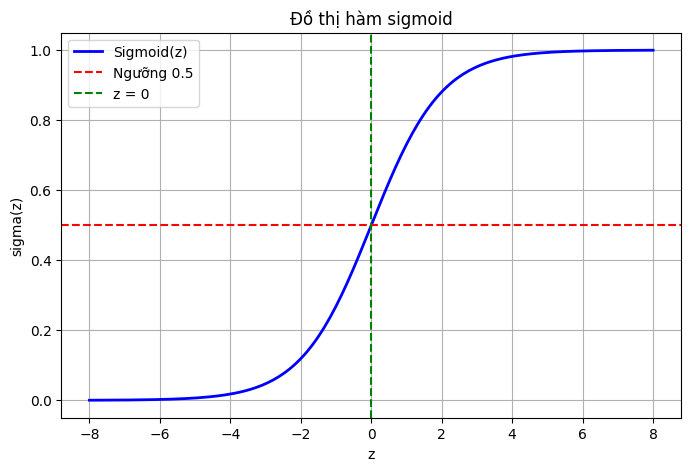

Đã vẽ và lưu đồ thị thành công vào tệp sigmoid.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


z = np.linspace(-8, 8, 200)
sig = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, sig, label="Sigmoid(z)", color="blue", linewidth=2)
plt.axhline(y=0.5, color="red", linestyle="--", label="Ngưỡng 0.5")
plt.axvline(x=0, color="green", linestyle="--", label="z = 0")

plt.title("Đồ thị hàm sigmoid")
plt.xlabel("z")
plt.ylabel("sigma(z)")
plt.legend()
plt.grid(True)

plt.savefig("sigmoid.png")
plt.show()
print("Đã vẽ và lưu đồ thị thành công vào tệp sigmoid.png")

In [15]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("/content/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression().fit(X, y)
w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])


def du_doan(gio):
    can_moi = pd.DataFrame({"gio_on": [gio]})
    prob = mo_hinh.predict_proba(can_moi)[0, 1]
    pred_nhan = mo_hinh.predict(can_moi)[0]
    z = w * gio + b
    print(
        f"Số giờ ôn: {gio:5.1f} | Giá trị z: {z:6.2f} | Xác suất qua: {prob:.4f} | Nhãn: {pred_nhan}"
    )


print("Kết quả dự đoán cho các bạn:")
for g in [3, 8, 12.89, 18, 26]:
    du_doan(g)

print()
print(
    "Giải thích: Tại mốc 12.89 giờ, ta có z = w*12.89 + b ≈ 0. Theo tính chất hàm sigmoid, sigma(0) = 0.5, do đó xác suất qua môn xấp xỉ bằng 0.5 (điểm phân vân của mô hình)."
)

Kết quả dự đoán cho các bạn:
Số giờ ôn:   3.0 | Giá trị z:  -3.89 | Xác suất qua: 0.0201 | Nhãn: 0
Số giờ ôn:   8.0 | Giá trị z:  -1.92 | Xác suất qua: 0.1276 | Nhãn: 0
Số giờ ôn:  12.9 | Giá trị z:  -0.00 | Xác suất qua: 0.4996 | Nhãn: 0
Số giờ ôn:  18.0 | Giá trị z:   2.01 | Xác suất qua: 0.8814 | Nhãn: 1
Số giờ ôn:  26.0 | Giá trị z:   5.15 | Xác suất qua: 0.9942 | Nhãn: 1

Giải thích: Tại mốc 12.89 giờ, ta có z = w*12.89 + b ≈ 0. Theo tính chất hàm sigmoid, sigma(0) = 0.5, do đó xác suất qua môn xấp xỉ bằng 0.5 (điểm phân vân của mô hình).


In [16]:

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Lấy 4 giá trị từ confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Tự tính thủ công
n = len(y_test)
accuracy = (tp + tn) / n
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = (
    (2 * precision * recall) / (precision + recall)
    if (precision + recall) > 0
    else 0
)

print("--- KẾT QUẢ TỰ TÍNH BẰNG CÔNG THỨC ---")
print(f"Accuracy  = ({tp} + {tn}) / {n} = {accuracy:.4f}")
print(f"Precision = {tp} / ({tp} + {fp}) = {precision:.4f}")
print(f"Recall    = {tp} / ({tp} + {fn}) = {recall:.4f}")
print(
    f"F1        = 2 * ({precision:.4f} * {recall:.4f}) / ({precision:.4f} + {recall:.4f}) = {f1:.4f}"
)

--- KẾT QUẢ TỰ TÍNH BẰNG CÔNG THỨC ---
Accuracy  = (17 + 9) / 30 = 0.8667
Precision = 17 / (17 + 3) = 0.8500
Recall    = 17 / (17 + 1) = 0.9444
F1        = 2 * (0.8500 * 0.9444) / (0.8500 + 0.9444) = 0.8947


In [17]:

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)
p = mo_hinh.predict_proba(X_test)[:, 1]

nguongs = np.arange(0.05, 1.0, 0.05)
best_f1 = -1
best_nguong = 0.5

print("Ngưỡng\t\tF1-Score")
print("-" * 25)
for ng in nguongs:
    y_pred = (p >= ng).astype(int)
    score = f1_score(y_test, y_pred, zero_division=0)
    print(f"{ng:.2f}\t\t{score:.4f}")
    if score > best_f1:
        best_f1 = score
        best_nguong = ng

print("-" * 25)
print(f"Ngưỡng cho F1 cao nhất là: {best_nguong:.2f} với F1 = {best_f1:.4f}")
print()
print(
    "Nhận xét: Ngưỡng tốt nhất theo F1 chưa chắc đã đúng bằng 0.5, vì nó phụ thuộc vào sự cân bằng giữa Precision và Recall trên tập kiểm tra cụ thể."
)

Ngưỡng		F1-Score
-------------------------
0.05		0.7826
0.10		0.8182
0.15		0.8182
0.20		0.8571
0.25		0.9000
0.30		0.8947
0.35		0.8947
0.40		0.8947
0.45		0.8947
0.50		0.8947
0.55		0.8889
0.60		0.9412
0.65		0.9412
0.70		0.9091
0.75		0.8750
0.80		0.8387
0.85		0.8000
0.90		0.5600
0.95		0.4348
-------------------------
Ngưỡng cho F1 cao nhất là: 0.60 với F1 = 0.9412

Nhận xét: Ngưỡng tốt nhất theo F1 chưa chắc đã đúng bằng 0.5, vì nó phụ thuộc vào sự cân bằng giữa Precision và Recall trên tập kiểm tra cụ thể.


In [18]:

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)
y_pred = mo_hinh.predict(X_test)

# Đổi lớp dương sang lớp 0 (rớt môn) bằng pos_label=0
pre_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
rec_0 = recall_score(y_test, y_pred, pos_label=0, zero_division=0)

print(f"Precision của lớp 0 (rớt môn): {pre_0:.4f}")
print(f"Recall của lớp 0 (rớt môn):    {rec_0:.4f}")
print()
print(
    "Giải thích: Khi đổi nhãn dương thành lớp 0 (rớt môn), định nghĩa về True Positive (TP), False Positive (FP), và False Negative (FN) bị đảo ngược hoàn toàn cho góc nhìn ngược lại. Do đó bộ số đo lường (Precision, Recall) thay đổi dù mô hình và dữ liệu không thay đổi."
)

Precision của lớp 0 (rớt môn): 0.9000
Recall của lớp 0 (rớt môn):    0.7500

Giải thích: Khi đổi nhãn dương thành lớp 0 (rớt môn), định nghĩa về True Positive (TP), False Positive (FP), và False Negative (FN) bị đảo ngược hoàn toàn cho góc nhìn ngược lại. Do đó bộ số đo lường (Precision, Recall) thay đổi dù mô hình và dữ liệu không thay đổi.
